In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
img_size = 224
batch_size = 32
dataset_path='Dataset/'
train_dir = os.path.join(dataset_path, 'train_another')
val_dir = os.path.join(dataset_path, 'validation_another')
test_dir = os.path.join(dataset_path, 'test_another')

In [4]:
train_datagen=ImageDataGenerator(rescale=1./255,
                                 rotation_range=30,
                                 horizontal_flip=True,
                                 width_shift_range=0.1,
                                 height_shift_range=0.1,
                                 zoom_range=0.2)
val_datagen=ImageDataGenerator(rescale=1./255)
test_datagen=ImageDataGenerator(rescale=1./255)

In [5]:
train_generator=train_datagen.flow_from_directory(train_dir,
                                                  target_size=(img_size,img_size),
                                                  batch_size=batch_size,
                                                  class_mode='binary',
                                                  shuffle=True)
val_generator=val_datagen.flow_from_directory(val_dir,
                                                target_size=(img_size,img_size),
                                                batch_size=batch_size,
                                                class_mode='binary',
                                                shuffle=False)
test_generator=test_datagen.flow_from_directory(test_dir,
                                                  target_size=(img_size,img_size),
                                                  batch_size=batch_size,
                                                  class_mode='binary',
                                                  shuffle=False)


Found 10000 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.
Found 9000 images belonging to 2 classes.


In [6]:
train_generator.class_indices

{'damage': 0, 'no_damage': 1}

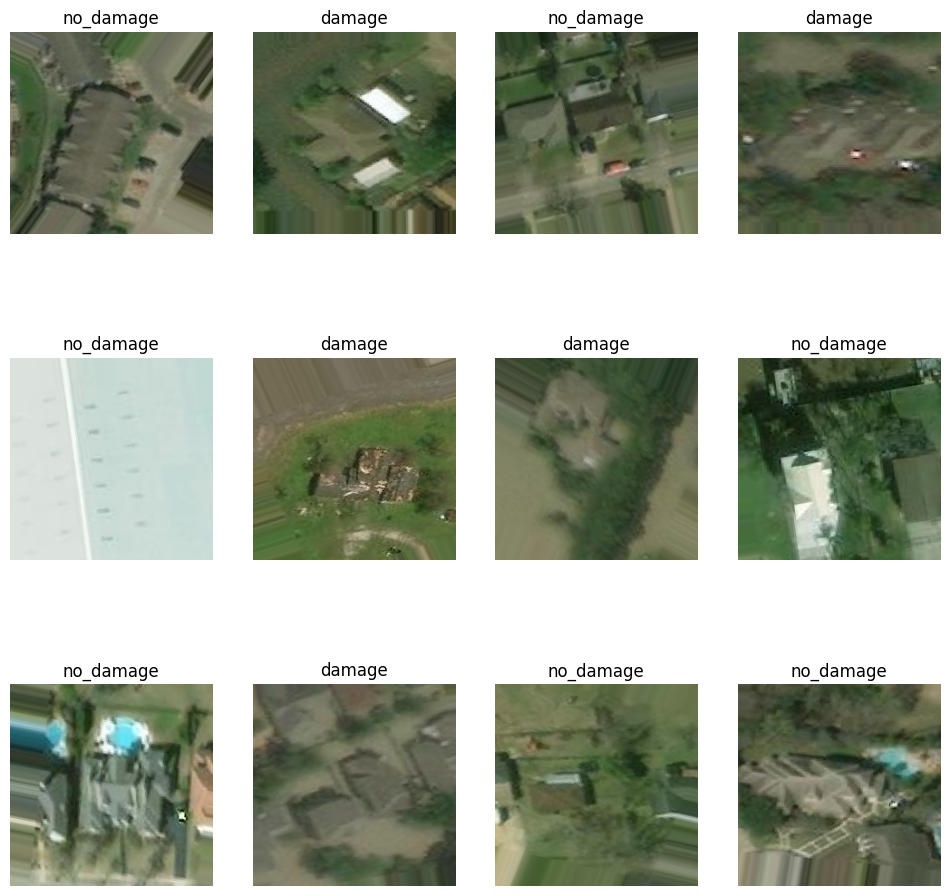

In [7]:
labels=list(train_generator.class_indices.keys())
images,targets=next(train_generator)
plt.figure(figsize=(12,12))
for i in range(12):
    
    plt.subplot(3,4,i+1)
    plt.imshow(images[i])
    
    label = labels[int(targets[i])]
    plt.title(label)
    
    plt.axis("off")

plt.show()

In [8]:
print("Training samples:", train_generator.samples)
print("Validation samples:", val_generator.samples)
print("Test samples:", test_generator.samples)

Training samples: 10000
Validation samples: 2000
Test samples: 9000


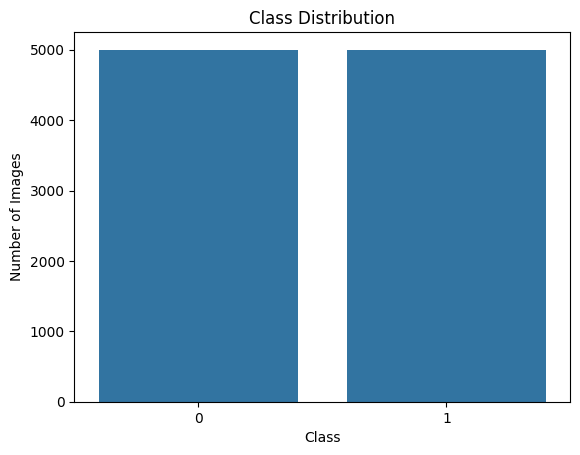

In [10]:
train_classes=train_generator.classes

sns.countplot(x=train_classes)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()